In [624]:
import numpy as np
import matplotlib.pyplot as plt

In [625]:
# Dimensions
no_of_sources=4
no_of_slots=3
P_total = 2.5
max_iters = 100
snr=50  #from o to snr

In [626]:
# --- Random initialization ---
np.random.seed(3)
H = np.random.randn(no_of_slots, no_of_sources)
x = np.random.uniform(-1, 1, size=(no_of_sources, 1))  # Uniform distribution between -1 and 1
z = np.random.randn(no_of_slots, 1)



eta = 0.01           # learning rate for B
eta_lambda = 0.1     # learning rate for lambda
tol = 1e-6

In [627]:
B = np.random.randn(no_of_slots, no_of_sources)  # Initial B value
print("B=",B,"\n")
lambda_reg = 1.0      # Initial value of lambda

for iter in range(max_iters):
    BH = B * H
    print("BH=",BH,"\n")
    y = BH @ x - np.sum(x)
    print("y=",y,"\n")
    grad = 2 * (y @ x.T) * H + 2 * lambda_reg * B

    # Gradient step
    B_new = B - eta * grad
    print("B_new=",B_new,"\n")
    colwise_norms = np.sum(B_new * B_new, axis=0)  # shape: (no_of_sources,)
    print("sum b_i(t)^2=",colwise_norms,"\n")
    print( (colwise_norms > P_total))
    # Check if any column has a squared norm greater than P_total
    if any(colwise_norms > P_total):
        
        for i in range(B_new.shape[1]):  # Iterate over each column
            if colwise_norms[i] > P_total:
                # Scale the column if its squared norm exceeds P_total
                B_new[:, i] = np.sqrt(P_total / colwise_norms[i])

        # Dual update: Based on the total column norms exceeding P_total
        total_col_sum = np.sum(colwise_norms)
        lambda_reg += eta_lambda * (total_col_sum - P_total)
        lambda_reg = max(0, lambda_reg)

    # Convergence check
    if np.linalg.norm(B_new - B, ord='fro') < tol:
        print(f"Converged at iteration {iter}")
        break

    # Update B
    B = B_new


B= [[-1.10106763 -1.18504653 -0.2056499   1.48614836]
 [ 0.23671627 -1.02378514 -0.7129932   0.62524497]
 [-0.16051336 -0.76883635 -0.23003072  0.74505627]] 

BH= [[-1.96940091 -0.51728448 -0.01984469 -2.76942662]
 [-0.0656623   0.36319697  0.05899411 -0.39202902]
 [ 0.0070334   0.36690257  0.30222926  0.65909345]] 

y= [[-0.79523565]
 [ 0.24063866]
 [ 0.15909505]] 

B_new= [[-1.06901821 -1.16008395 -0.20299805  1.45293672]
 [ 0.23245254 -1.00299916 -0.69911245  0.61309526]
 [-0.15725395 -0.75318368 -0.22941018  0.72982382]] 

sum b_i(t)^2= [1.22156293 2.91908776 0.58259546 3.01955371] 

[False  True False  True]
BH= [[-1.91207641  0.40396197 -0.0195888  -1.69561138]
 [-0.06447959 -0.32830676  0.0578456  -0.57051443]
 [ 0.00689058 -0.44163478  0.30141395  0.8049271 ]] 

y= [[-0.48146089]
 [ 0.09547586]
 [ 0.03005476]] 

B_new= [[-1.03035724  0.89798745 -0.19769416  0.88005907]
 [ 0.22555281  0.89734671 -0.67795001  0.88231216]
 [-0.15245068  0.89727574 -0.22316835  0.88210864]] 

sum b

In [628]:
# Function to compute MMSE for one round
def compute_mmse(B, H, x, snr_db):
    n = B.shape[0]
    BH = B * H
    signal = BH @ x
    P_signal = np.sum(x**2) / n
    snr_linear = 10 ** (snr_db / 10)
    P_noise = P_signal / snr_linear
    z = np.random.normal(0, np.sqrt(P_noise), size=(n, 1))
    y = signal + z
    target = np.sum(x)
    mmse = np.sum((y - target) ** 2) / n
    return mmse

In [629]:
snrs = np.arange(0, snr+1)
mmse_vals = []
for snr_db in snrs:
    mmse_list = [compute_mmse(B, H, x, snr_db) for _ in range(max_iters)]
    mmse_vals.append(np.mean(mmse_list))
    
print("mse",mmse_vals)

mse [0.4509915154950427, 0.3322577302067771, 0.27390386233658615, 0.21599990628816607, 0.20639498297037473, 0.15008637626223081, 0.13546553584512805, 0.12216162652412638, 0.09599170987160532, 0.09012913306485165, 0.08041626027784889, 0.07560911986692698, 0.07118918822660332, 0.06578903228893936, 0.06396625006996126, 0.05196686415388701, 0.05631662296383288, 0.05892342243551399, 0.05164768227636955, 0.05549173382898137, 0.0519988768275158, 0.05241004172764446, 0.05475201014796787, 0.05244628701106258, 0.05238486987018581, 0.05107453733194084, 0.050540865748520875, 0.05169667117156203, 0.05160407006393864, 0.05085991426090253, 0.050650843580797265, 0.04949469974863145, 0.05059024834002232, 0.0501244046772552, 0.05017692924636423, 0.05083859230634883, 0.05044061709138975, 0.050222422057576696, 0.050631261179475306, 0.05035917730937961, 0.05049452285520296, 0.050453229615266604, 0.0502107445608617, 0.05029089332020318, 0.05044251351273918, 0.050491881040446565, 0.05037121991090889, 0.05034

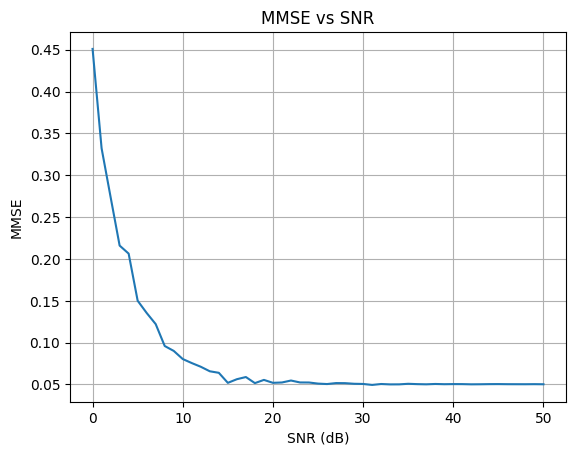

In [630]:
# Plot

plt.plot(snrs, mmse_vals)
plt.xlabel('SNR (dB)')
plt.ylabel('MMSE')
plt.title('MMSE vs SNR')
plt.grid(True)
plt.show()